In [15]:
import pandas as pd
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env
import sys
import os
sys.path.append(os.path.abspath('..'))  # go one level up

from scripts.gpu_env import GpuEnv

# Load the data
workload_data = pd.read_csv('../data/workload_simulation.csv')

# Create environment
env = GpuEnv(workload_data)

In [16]:
from stable_baselines3 import PPO

# (Optional) Check if the environment follows Gym API
# check_env(env, warn=True)

# Define the PPO RL model
model = PPO("MlpPolicy", env,
            learning_rate=1e-3,
            gamma=0.95,
            ent_coef=0.01,  # Encourage exploration
            verbose=1)

# Train the model
model.learn(total_timesteps=29000)

# Save the model
model.save("../models/ppo_gpu_allocator")

print("✅ Training complete and model saved!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


C:\Users\SAMAD MEHNDI\AppData\Roaming\Python\Python312\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


----------------------------------
| rollout/           |           |
|    ep_len_mean     | 24        |
|    ep_rew_mean     | -2.36e+03 |
| time/              |           |
|    fps             | 798       |
|    iterations      | 1         |
|    time_elapsed    | 2         |
|    total_timesteps | 2048      |
----------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 24           |
|    ep_rew_mean          | -2.31e+03    |
| time/                   |              |
|    fps                  | 595          |
|    iterations           | 2            |
|    time_elapsed         | 6            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0054225535 |
|    clip_fraction        | 0.0531       |
|    clip_range           | 0.2          |
|    entropy_loss         | -4.25        |
|    explained_variance   | 0.000269     |
|    

Hour 1 | Action: [0.871454   0.25233865 0.71636593] | Alloc: [47.357548 13.712874 38.929577] | Demand: [46.49014246 27.27808638 41.71809145]
Hour 2 | Action: [1.         0.73199975 0.8867749 ] | Alloc: [38.185795 27.951994 33.862206] | Demand: [44.5852071  30.55461295 35.16881012]
Hour 3 | Action: [0.7003905 0.        0.6502366] | Alloc: [51.85669  0.      48.14331] | Demand: [46.94306561 24.24503211 48.92877949]
Hour 4 | Action: [0.7160806  0.13549772 0.6459354 ] | Alloc: [47.817966  9.048179 43.133858] | Demand: [49.56908957 31.87849009 47.49719782]
Hour 5 | Action: [0.6014584  0.0123332  0.63328004] | Alloc: [48.22966     0.98897254 50.78137   ] | Demand: [44.29753988 26.99680655 46.59207769]
Hour 6 | Action: [0.40974033 0.00850968 0.67746294] | Alloc: [37.394863    0.77663416 61.828506  ] | Demand: [44.29758913 28.54153125 51.93723363]
Hour 7 | Action: [0.6781027 0.        0.6363797] | Alloc: [51.587044  0.       48.41295 ] | Demand: [49.73763845 26.99146694 51.46587706]
Hour 8 | A

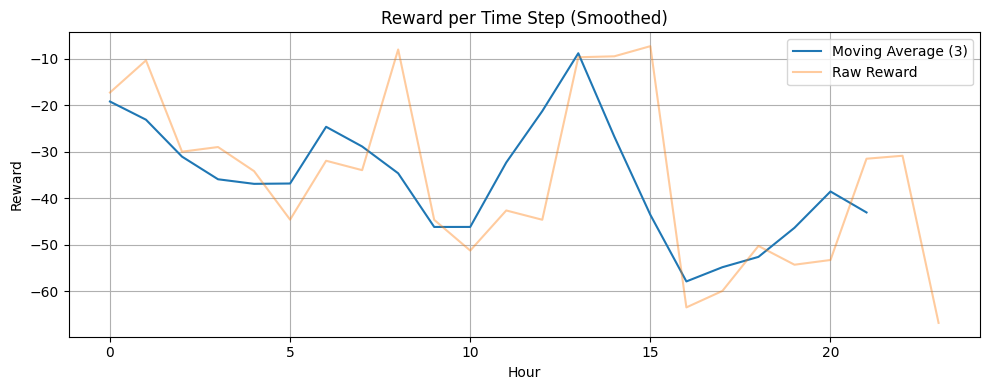

🎯 Total Reward for the Episode: -858.25


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from stable_baselines3 import PPO
from scripts.gpu_env import GpuEnv

# Load the trained model
model = PPO.load("../models/ppo_gpu_allocator")

# Reload the environment
# workload_data = pd.read_csv('../data/workload_simulation.csv')
# env = GpuEnv(workload_data)

# Run a test episode
state = env.reset()
allocations = []
demands = []
rewards = []
done = False

while not done:
    action, _ = model.predict(state, deterministic=True)

    demands.append(state)

    # Scale action manually (PPO outputs 0–1)
    action = np.clip(action, 0, 1)
    scaled = action * 100
    alloc = (scaled / scaled.sum()) * 100 if scaled.sum() > 0 else np.ones(3) * (100 / 3)
    allocations.append(alloc)

    print(f"Hour {len(allocations)} | Action: {action} | Alloc: {alloc} | Demand: {state}")
    state, reward, done, _ = env.step(action)
    rewards.append(reward)

def moving_average(x, window=3):
    return np.convolve(x, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(moving_average(rewards, window=3), label="Moving Average (3)")
plt.plot(rewards, alpha=0.4, label="Raw Reward")
plt.title("Reward per Time Step (Smoothed)")
plt.xlabel("Hour")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"🎯 Total Reward for the Episode: {sum(rewards):.2f}")


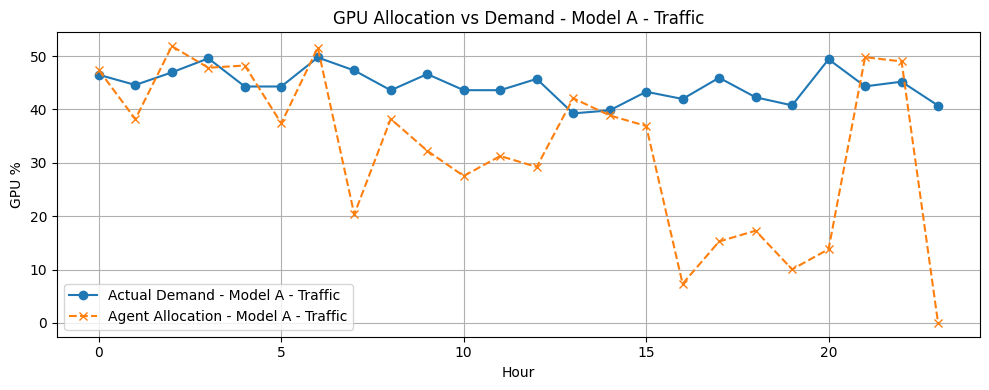

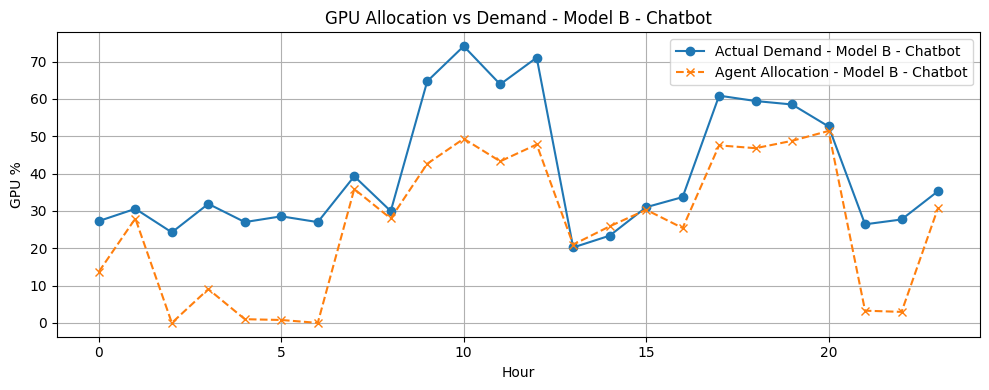

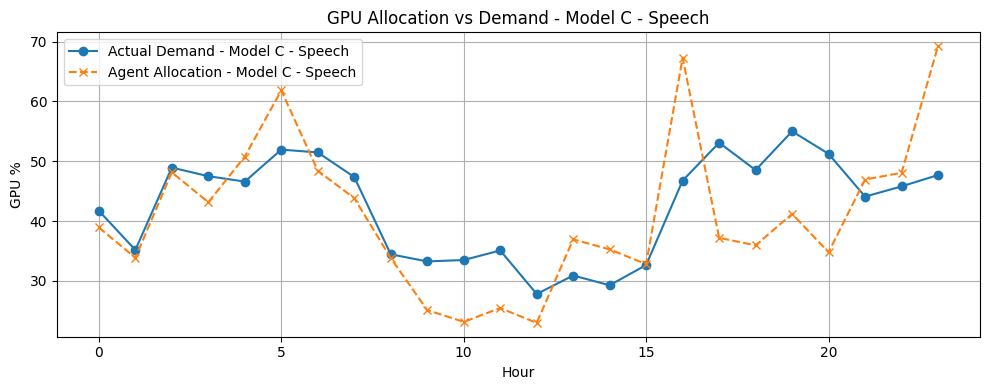

In [18]:
# Convert lists to numpy arrays
allocations = np.array(allocations)
demands = np.array(demands)
hours = np.arange(len(allocations))

# Plot GPU allocation vs demand for each model
model_names = ['Model A - Traffic', 'Model B - Chatbot', 'Model C - Speech']

for i in range(3):
    plt.figure(figsize=(10, 4))
    plt.plot(hours, demands[:, i], label=f"Actual Demand - {model_names[i]}", marker='o')
    plt.plot(hours, allocations[:, i], label=f"Agent Allocation - {model_names[i]}", linestyle='--', marker='x')
    plt.title(f"GPU Allocation vs Demand - {model_names[i]}")
    plt.xlabel("Hour")
    plt.ylabel("GPU %")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [19]:
# Compute penalties
import numpy as np

allocations = np.array(allocations)
demands = np.array(demands)

under_allocation = np.maximum(0, demands - allocations)
over_allocation = np.maximum(0, allocations - demands)
total_penalty = np.abs(allocations - demands)

# Aggregate across all models and time
under_penalty_sum = np.sum(under_allocation)
over_penalty_sum = np.sum(over_allocation)
total_error_sum = np.sum(total_penalty)

print(f"🟥 Total Under-Allocation Penalty: {under_penalty_sum:.2f}")
print(f"🟦 Total Over-Allocation (Wasted GPU): {over_penalty_sum:.2f}")
print(f"✅ Total Absolute Error: {total_error_sum:.2f}")

🟥 Total Under-Allocation Penalty: 757.90
🟦 Total Over-Allocation (Wasted GPU): 100.34
✅ Total Absolute Error: 858.25


In [20]:
import pandas as pd

df = pd.DataFrame({
    'Hour': np.arange(len(allocations)),
    'Model_A_Actual': demands[:, 0],
    'Model_A_Allocated': allocations[:, 0],
    'Model_B_Actual': demands[:, 1],
    'Model_B_Allocated': allocations[:, 1],
    'Model_C_Actual': demands[:, 2],
    'Model_C_Allocated': allocations[:, 2],
})

df.to_csv("../results/ppo_allocation_vs_demand.csv", index=False)
print("✅ CSV exported to results/ppo_allocation_vs_demand.csv")


✅ CSV exported to results/ppo_allocation_vs_demand.csv
